# Experiment No. 02: Delta Modulation

## Title
**Delta Modulation and Demodulation using Python**

## Aim
To implement Delta Modulation and Demodulation for an analog message signal and observe proper delta modulation, slope-overload distortion, and granular noise.

## Experimental Requirements
- Python 3
- Jupyter Notebook or Google Colab
- NumPy
- Matplotlib

## Theory

Delta Modulation (DM) is an analog-to-digital conversion technique in which only the change in signal amplitude from one sample to the next is transmitted.

Unlike Pulse Code Modulation, which represents the amplitude of every sample using several bits, Delta Modulation uses only **one bit per sample**.

At every sampling instant, the input signal is compared with the previous value of a staircase approximation.

- If the input signal is greater than the previous staircase value, bit `1` is generated and the staircase increases by $\Delta$.
- If the input signal is less than or equal to the previous staircase value, bit `0` is generated and the staircase decreases by $\Delta$.

Here, $\Delta$ is called the **step size**.

### Error Signal

The difference between the present input sample and the previous staircase value is

$$
e[n] = x[n] - \hat{x}[n-1]
$$

where:

- $x[n]$ is the input sample,
- $\hat{x}[n-1]$ is the previous staircase approximation.

### One-Bit Quantization

The transmitted binary bit is

$$
b[n] =
\begin{cases}
1, & e[n] > 0 \\
0, & e[n] \leq 0
\end{cases}
$$

The corresponding quantized difference is

$$
q[n] =
\begin{cases}
+\Delta, & b[n]=1 \\
-\Delta, & b[n]=0
\end{cases}
$$

### Staircase Generation

The staircase approximation is generated recursively as

$$
\hat{x}[n] = \hat{x}[n-1] + q[n]
$$

or equivalently,

$$
\hat{x}[n] = \hat{x}[n-1] + (2b[n]-1)\Delta
$$

## Delta Modulator

A Delta Modulator contains:

1. Comparator
2. One-bit quantizer
3. Accumulator or staircase generator
4. Delay element

The comparator compares the current message-signal sample with the previous staircase value. The one-bit quantizer generates either `1` or `0`, and the accumulator updates the staircase approximation by adding or subtracting the step size.

## Delta Demodulator

At the receiver, the received binary sequence is accumulated:

- Bit `1` adds $+\Delta$.
- Bit `0` adds $-\Delta$.

This produces the decoded staircase signal. A low-pass reconstruction filter smooths the staircase signal to obtain an approximation of the original analog message signal.

## Delta Modulation System Flow

**Message Signal → Comparator → One-Bit Quantizer → DM Bit Stream**

**DM Bit Stream → Accumulator → Low-Pass Filter → Recovered Signal**

## Distortions in Delta Modulation

### 1. Slope-Overload Distortion

Slope-overload distortion occurs when the input signal changes faster than the staircase signal can follow.

The maximum tracking slope of the staircase is approximately

$$
\frac{\Delta}{T_s} = \Delta f_s
$$

Therefore, proper tracking requires

$$
\Delta f_s \geq \max\left|\frac{dx(t)}{dt}\right|
$$

For a sinusoidal signal

$$
x(t)=A\sin(2\pi f_m t)
$$

the maximum input slope is

$$
\max\left|\frac{dx(t)}{dt}\right|=2\pi f_m A
$$

Thus, the approximate condition for avoiding slope overload is

$$
\Delta f_s \geq 2\pi f_m A
$$

Slope overload can be reduced by:

- Increasing the step size $\Delta$
- Increasing the sampling frequency
- Reducing the message-signal frequency or amplitude

### 2. Granular Noise

Granular noise occurs when the step size is too large compared with the small or slowly varying changes of the input signal.

The staircase repeatedly moves above and below the input signal, producing unwanted oscillations.

Granular noise can be reduced by decreasing the step size.

## Step-Size Trade-Off

A small step size provides good accuracy for slowly varying signals but may produce slope-overload distortion during rapid changes.

A large step size follows rapid changes more effectively but produces more granular noise in slowly varying regions.

Adaptive Delta Modulation improves performance by automatically changing the step size according to the rate of change of the input signal.

## Experimental Cases

### Case 1: Proper Delta Modulation
A suitable message-signal variation and step size are selected so that the staircase approximation follows the input signal properly.

### Case 2: Slope-Overload Distortion
The input signal changes more rapidly while the step size remains fixed. The staircase cannot follow the rapid input variation.

### Case 3: Granular Noise
A slowly varying input signal is used with a relatively large step size. The staircase oscillates around the message signal.

## Algorithm

1. Generate the sinusoidal message signal.
2. Initialize the staircase approximation to zero.
3. Compare every input sample with the previous staircase value.
4. Generate bit `1` if the input is greater than the staircase value.
5. Generate bit `0` otherwise.
6. Increase the staircase by $\Delta$ for bit `1`.
7. Decrease the staircase by $\Delta$ for bit `0`.
8. Transmit the generated one-bit Delta Modulation sequence.
9. Accumulate the received bits at the demodulator.
10. Apply a smoothing filter to obtain the recovered signal.
11. Calculate the tracking error and mean squared error.
12. Repeat the process for proper DM, slope overload, and granular noise.
13. Plot all input, staircase, binary, decoded, and reconstructed signals.

## Output

The program displays:

1. Original message signal
2. Staircase approximation
3. Delta-Modulated binary sequence
4. Decoded staircase signal
5. Reconstructed message signal
6. Tracking mean squared error
7. Proper Delta Modulation
8. Slope-overload distortion
9. Granular noise

## Result and Discussion

Delta Modulation and Demodulation were successfully implemented using Python.

In Case 1, the selected step size allowed the staircase approximation to follow the input message signal closely.

In Case 2, the input signal changed too rapidly for the fixed staircase step size. Consequently, the staircase remained behind the input waveform, demonstrating slope-overload distortion.

In Case 3, the input signal changed slowly compared with the selected step size. The staircase repeatedly moved above and below the input signal, demonstrating granular noise.

The experiment shows that Delta Modulation performance depends strongly on the relationship among message-signal slope, sampling frequency, and step size.

## Conclusion

Delta Modulation and Demodulation were successfully implemented. The experiment demonstrated one-bit encoding, staircase generation, accumulation, signal reconstruction, slope-overload distortion, and granular noise.

A small step size reduces granular noise but increases the possibility of slope overload. A large step size improves rapid tracking but increases granular noise. Therefore, the step size must be selected carefully, or Adaptive Delta Modulation may be used.

Case 1: Proper Delta Modulation
Step size, delta = 0.2
First 30 DM bits = 011111110111101101010101010010
Tracking MSE = 0.014034
-----------------------------------------------------------------
Case 2: Slope-Overload Distortion
Step size, delta = 0.2
First 30 DM bits = 011111111111001000000000000000
Tracking MSE = 0.293169
-----------------------------------------------------------------
Case 3: Granular Noise
Step size, delta = 0.23
First 30 DM bits = 011101101101011011011010110101
Tracking MSE = 0.018189
-----------------------------------------------------------------


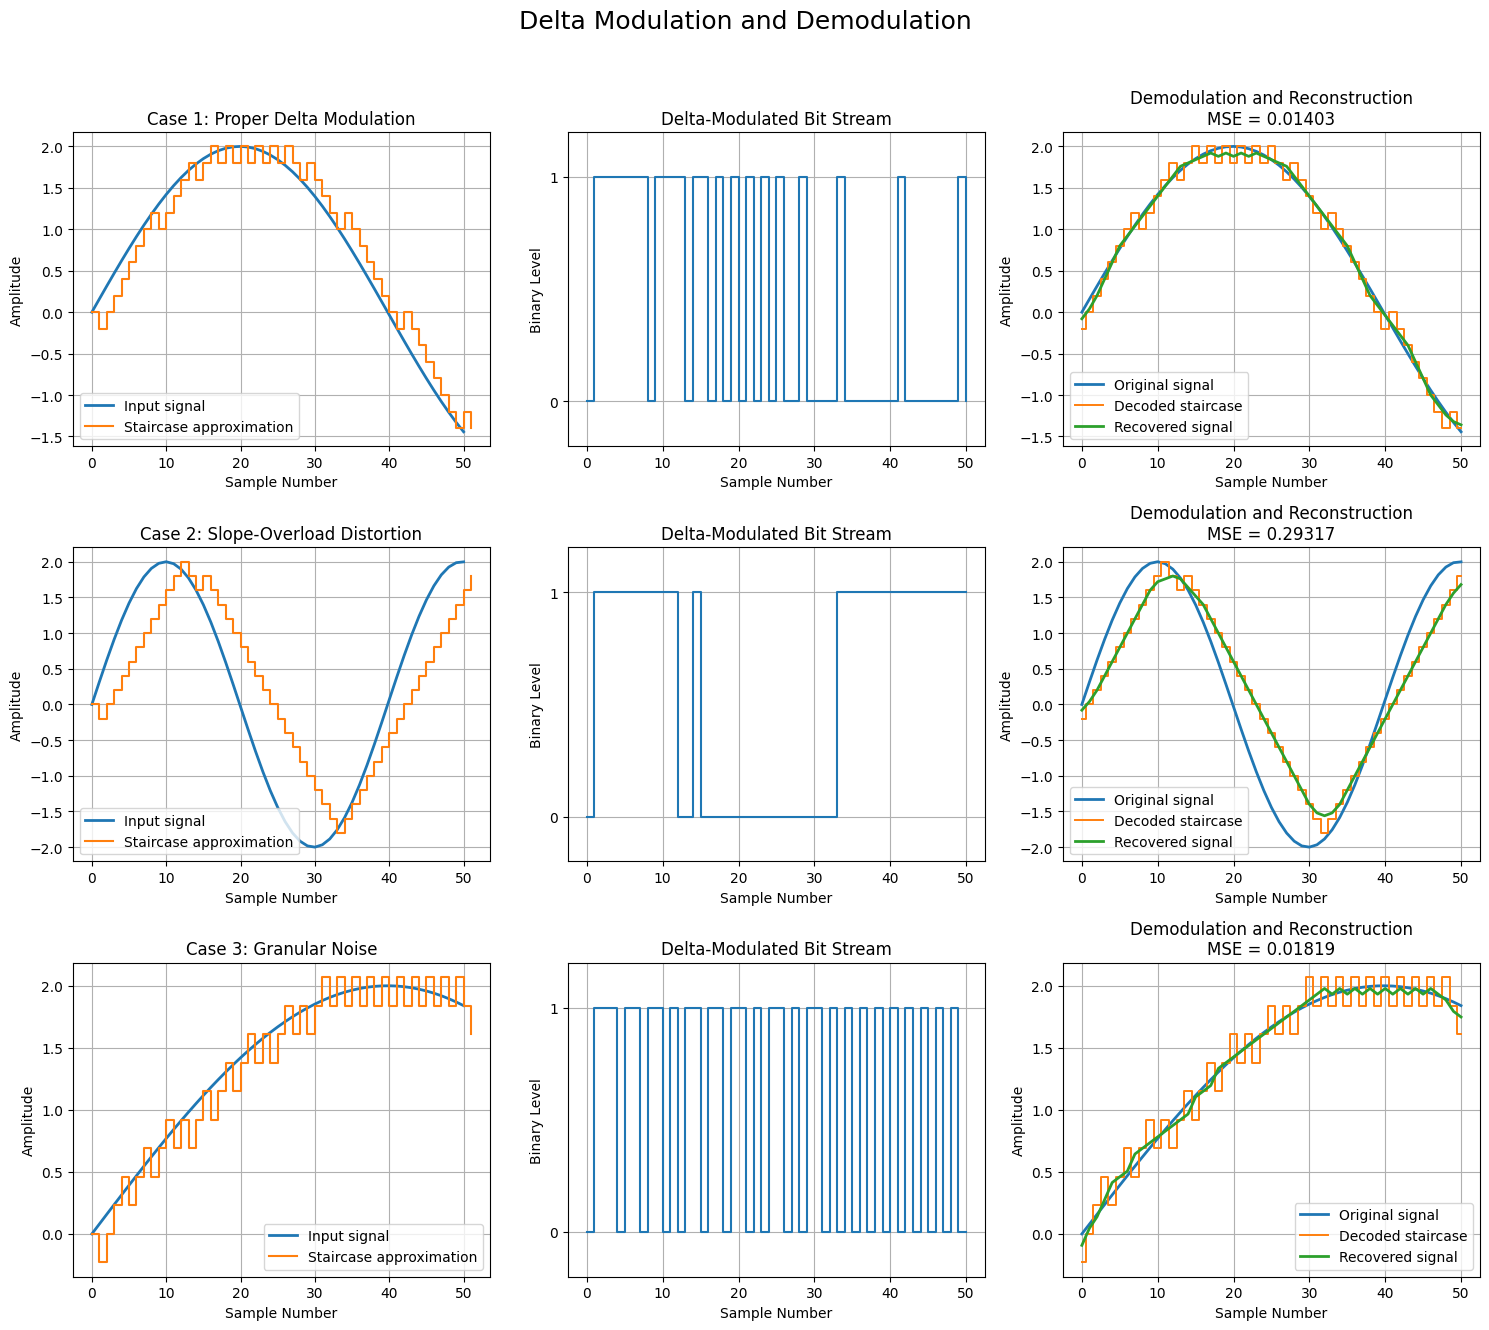

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def delta_modulate(signal, delta, initial_level=0.0):
    """
    Perform one-bit Delta Modulation.

    Parameters
    ----------
    signal : array-like
        Sampled input message signal.
    delta : float
        Fixed staircase step size.
    initial_level : float
        Initial value of the staircase approximation.

    Returns
    -------
    bits : ndarray
        Delta-Modulated binary sequence.
    staircase : ndarray
        Staircase signal including its initial value.
    """

    signal = np.asarray(signal, dtype=float)

    if signal.ndim != 1:
        raise ValueError("The input signal must be one-dimensional.")

    if delta <= 0:
        raise ValueError("The step size delta must be positive.")

    bits = np.zeros(len(signal), dtype=int)

    # One extra element is required to store the initial staircase value.
    staircase = np.zeros(len(signal) + 1, dtype=float)
    staircase[0] = initial_level

    for n, sample in enumerate(signal):

        # The condition follows the supplied MATLAB laboratory program.
        if sample > staircase[n]:
            bits[n] = 1
            staircase[n + 1] = staircase[n] + delta

        else:
            bits[n] = 0
            staircase[n + 1] = staircase[n] - delta

    return bits, staircase


def delta_demodulate(bits, delta, initial_level=0.0):
    """
    Demodulate a Delta-Modulated binary sequence.

    Bit 1 represents +delta.
    Bit 0 represents -delta.
    """

    bits = np.asarray(bits, dtype=int)

    if bits.ndim != 1:
        raise ValueError("The DM bit stream must be one-dimensional.")

    if not np.all(np.isin(bits, [0, 1])):
        raise ValueError("The DM sequence can contain only binary 0 and 1.")

    if delta <= 0:
        raise ValueError("The step size delta must be positive.")

    decoded = np.zeros(len(bits), dtype=float)
    current_level = initial_level

    for n, bit in enumerate(bits):

        if bit == 1:
            current_level += delta
        else:
            current_level -= delta

        decoded[n] = current_level

    return decoded


def moving_average(signal, window_size=5):
    """
    Apply a simple moving-average low-pass reconstruction filter.
    """

    signal = np.asarray(signal, dtype=float)

    if window_size < 1 or window_size % 2 == 0:
        raise ValueError(
            "window_size must be a positive odd integer."
        )

    padding = window_size // 2

    # Edge padding prevents a large drop at the two boundaries.
    padded_signal = np.pad(
        signal,
        (padding, padding),
        mode="edge"
    )

    filter_coefficients = (
        np.ones(window_size, dtype=float) / window_size
    )

    reconstructed = np.convolve(
        padded_signal,
        filter_coefficients,
        mode="valid"
    )

    return reconstructed


# ---------------------------------------------------------
# Parameters adapted from Experiment 2 in the lab manual
# ---------------------------------------------------------

amplitude = 2

# MATLAB equivalent:
# t = 0 : 2*pi/50 : 2*pi
sample_step = 2 * np.pi / 50

t = np.arange(
    0,
    2 * np.pi + sample_step / 2,
    sample_step
)


# ---------------------------------------------------------
# Three experimental cases
# ---------------------------------------------------------

cases = [
    {
        "name": "Case 1: Proper Delta Modulation",

        # MATLAB equivalent:
        # x = a*sin(2*pi/10*t)
        "signal": amplitude * np.sin(
            (2 * np.pi / 10) * t
        ),

        "delta": 0.20
    },

    {
        "name": "Case 2: Slope-Overload Distortion",

        # A faster-changing message signal
        # MATLAB equivalent:
        # x = a*sin(2*pi/5*t)
        "signal": amplitude * np.sin(
            (2 * np.pi / 5) * t
        ),

        "delta": 0.20
    },

    {
        "name": "Case 3: Granular Noise",

        # A slowly changing message signal
        # MATLAB equivalent:
        # x = a*sin(2*pi/20*t)
        "signal": amplitude * np.sin(
            (2 * np.pi / 20) * t
        ),

        "delta": 0.23
    }
]


# ---------------------------------------------------------
# Modulation, demodulation and error calculation
# ---------------------------------------------------------

results = []

for case in cases:

    bits, staircase = delta_modulate(
        signal=case["signal"],
        delta=case["delta"],
        initial_level=0.0
    )

    decoded = delta_demodulate(
        bits=bits,
        delta=case["delta"],
        initial_level=0.0
    )

    reconstructed = moving_average(
        decoded,
        window_size=5
    )

    tracking_error = case["signal"] - decoded

    mse = np.mean(tracking_error ** 2)

    result = {
        "name": case["name"],
        "signal": case["signal"],
        "delta": case["delta"],
        "bits": bits,
        "staircase": staircase,
        "decoded": decoded,
        "reconstructed": reconstructed,
        "tracking_error": tracking_error,
        "mse": mse
    }

    results.append(result)

    print(case["name"])
    print("Step size, delta =", case["delta"])
    print(
        "First 30 DM bits =",
        "".join(bits[:30].astype(str))
    )
    print("Tracking MSE =", round(mse, 6))
    print("-" * 65)


# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------

sample_number = np.arange(len(t))

# Includes the initial staircase value.
staircase_sample_number = np.arange(len(t) + 1)

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 13)
)

for row, result in enumerate(results):

    # -----------------------------------------------------
    # Column 1: Input and staircase approximation
    # -----------------------------------------------------

    axes[row, 0].plot(
        sample_number,
        result["signal"],
        linewidth=2,
        label="Input signal"
    )

    axes[row, 0].step(
        staircase_sample_number,
        result["staircase"],
        where="post",
        linewidth=1.5,
        label="Staircase approximation"
    )

    axes[row, 0].set_title(result["name"])
    axes[row, 0].set_xlabel("Sample Number")
    axes[row, 0].set_ylabel("Amplitude")
    axes[row, 0].grid()
    axes[row, 0].legend()


    # -----------------------------------------------------
    # Column 2: Delta-Modulated binary waveform
    # -----------------------------------------------------

    axes[row, 1].step(
        sample_number,
        result["bits"],
        where="post",
        linewidth=1.5
    )

    axes[row, 1].set_title(
        "Delta-Modulated Bit Stream"
    )

    axes[row, 1].set_xlabel("Sample Number")
    axes[row, 1].set_ylabel("Binary Level")
    axes[row, 1].set_yticks([0, 1])
    axes[row, 1].set_ylim(-0.2, 1.2)
    axes[row, 1].grid()


    # -----------------------------------------------------
    # Column 3: Demodulation and reconstruction
    # -----------------------------------------------------

    axes[row, 2].plot(
        sample_number,
        result["signal"],
        linewidth=2,
        label="Original signal"
    )

    axes[row, 2].step(
        sample_number,
        result["decoded"],
        where="mid",
        linewidth=1.4,
        label="Decoded staircase"
    )

    axes[row, 2].plot(
        sample_number,
        result["reconstructed"],
        linewidth=2,
        label="Recovered signal"
    )

    axes[row, 2].set_title(
        "Demodulation and Reconstruction\n"
        f"MSE = {result['mse']:.5f}"
    )

    axes[row, 2].set_xlabel("Sample Number")
    axes[row, 2].set_ylabel("Amplitude")
    axes[row, 2].grid()
    axes[row, 2].legend()


plt.suptitle(
    "Delta Modulation and Demodulation",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()